# Actividad | Análisis descriptivo

Se selecciono el reporte correspondiente al año del 2015 siendo identificado por el archivo WHR_2015.vsc

# 1. Identificar las variables disponibles

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

file_name = 'WHR_2015.csv'

# Load data into a pandas DataFrame
df = pd.read_csv(file_name)

# Mostramos todas las variables del DataFrame
print(df.columns)

# mostramos las unidades de medida de cada variable
print(df.dtypes)

Index(['country', 'region', 'happiness_score', 'gdp_per_capita',
       'social_support', 'healthy_life_expectancy',
       'freedom_to_make_life_choices', 'generosity',
       'perceptions_of_corruption'],
      dtype='str')
country                             str
region                              str
happiness_score                 float64
gdp_per_capita                  float64
social_support                  float64
healthy_life_expectancy         float64
freedom_to_make_life_choices    float64
generosity                      float64
perceptions_of_corruption       float64
dtype: object


| Variable | Definición | Unidades de medida | Tipo de variable | Función (Rol) |
| :--- | :--- | :--- | :--- | :--- |
| `country` | Nombre del país al que corresponden los estadísticos. | N/A | Categórica nominal | **Identificador** |
| "region" | Región geográfica del mundo a la que pertenece el país. | N/A | Categórica nominal | **Grupo** |
| "happiness_score" | Promedio nacional de las respuestas a preguntas relacionadas con la evaluación de vida. | Puntos (0–10) | Numérica continua | **Respuesta** |
| "gdp_per_capita" | Producto interno bruto de un país dividido entre su población; representa el nivel económico promedio por habitante, ajustado por el poder adquisitivo. | Dólares internacionales (PPP) | Numérica continua | **Explicativa** |
| "social_support" | Promedio nacional de las respuestas a la pregunta de si una persona tiene familiares o amigos en quienes puede confiar y contar para recibir ayuda cuando lo necesita. | Puntos de contribucion | Numérica continua | **Explicativa** |
| "healthy_life_expectancy" | Número estimado de años que una persona puede esperar vivir con buena salud desde su nacimiento, considerando las condiciones de salud de la población de su país (normalizado). | Puntos de contribucion | Numérica continua | **Explicativa** |
| "freedom_to_make_life_choices" | Promedio de las respuestas a la pregunta sobre si las personas están satisfechas con su libertad para elegir qué hacer con su vida. | Proporción (0–1) | Numérica continua | **Explicativa** |
| "generosity" | Medida de la generosidad de un país basada en las respuestas sobre si las personas han donado a alguna organización benéfica durante el último mes, ajustada por el PIB per cápita. | Proporción (0–1) | Numérica continua | **Explicativa** |
| "perceptions_of_corruption" | Promedio nacional de la percepción de los ciudadanos sobre el nivel de corrupción en el gobierno y en las empresas. | Proporción (0–1) | Numérica continua | **Explicativa** |

En este caso no hay una muestra en especifico sino una poblacion la cual incluye todos los paises que fueron incluidos en el reporte. En caso de que se quisiera hacer una muetsra se podrian eleguir paises de forma aleatoria de esta poblacion para formar la muestra.

# 2. Revisar la calidad de los datos

Numero de observaciones

In [3]:
# Mostrar el numero de observaciones y variables del DataFrame
print( f"Numero de observaciones: {df.shape[0]}, Numero de variables: {df.shape[1]}")

Numero de observaciones: 158, Numero de variables: 9


### Identificar datos faltantes por variable.

In [4]:
# Checamos si hay valores faltantes en el DataFrame
print(df.isnull().sum())

country                         0
region                          0
happiness_score                 0
gdp_per_capita                  0
social_support                  0
healthy_life_expectancy         0
freedom_to_make_life_choices    0
generosity                      0
perceptions_of_corruption       0
dtype: int64


### Identificar los tipos de datos

In [5]:
#impriminos el tipo de datos de cada columna
print(df.dtypes)

country                             str
region                              str
happiness_score                 float64
gdp_per_capita                  float64
social_support                  float64
healthy_life_expectancy         float64
freedom_to_make_life_choices    float64
generosity                      float64
perceptions_of_corruption       float64
dtype: object


En este caso no se detecto ningun valor faltante pero se observo que estos fueron remplazados por 0 previamente. Entonces se decidio eliminar estos registros, ya que dejarlos y remplazarlos podria sesgar los resultados de los estadisticos siguientes.

In [6]:
print(f"Total de registros antes de eliminar los con valores faltantes: {len(df)}")

# Transformando 0 s a NaN en todas las columnas del DataFrame
df.replace(0, np.nan, inplace=True)

print(df.isnull().sum())




Total de registros antes de eliminar los con valores faltantes: 158
country                         0
region                          0
happiness_score                 0
gdp_per_capita                  1
social_support                  1
healthy_life_expectancy         1
freedom_to_make_life_choices    1
generosity                      1
perceptions_of_corruption       1
dtype: int64


### Checamos las estadísticas de estas columnas con valores 0 (ahorra nans) para ver si hay valores mínimos similares o no. 

In [7]:
# Checamos las estadisticas descriptiva de las columnas con valores nans

print(df.describe())



       happiness_score  gdp_per_capita  social_support  \
count       158.000000      157.000000      157.000000   
mean          5.375734        0.851527        0.997358   
std           1.145010        0.398660        0.261389   
min           2.839000        0.015300        0.139950   
25%           4.526000        0.546490        0.860400   
50%           5.232500        0.918510        1.032760   
75%           6.243750        1.159910        1.216240   
max           7.587000        1.690420        1.402230   

       healthy_life_expectancy  freedom_to_make_life_choices  generosity  \
count               157.000000                    157.000000  157.000000   
mean                  0.634274                      0.431345    0.238807   
std                   0.242644                      0.147203    0.125653   
min                   0.047760                      0.076990    0.001990   
25%                   0.440550                      0.328780    0.152750   
50%                  

En este caso se observo que existian multiples valores muy cercanos a 0 por lo cual se decidiÓ dejarlos considerando que las variables en las cuales se observo el 0 eran resultados de variables de proporciones o variables que se normalizaron.

In [8]:
# remplazar nans por 0
df.fillna(0, inplace=True)

# Checamos el numero de valores nans en el DataFrame
print(df.isnull().sum())

country                         0
region                          0
happiness_score                 0
gdp_per_capita                  0
social_support                  0
healthy_life_expectancy         0
freedom_to_make_life_choices    0
generosity                      0
perceptions_of_corruption       0
dtype: int64


## Revisar registros duplicados

In [9]:
# Checamos si hay valores duplicados en el DataFrame
print(df.duplicated().sum())

0


### Revisamos si existen duplicados en los nombres
No hay duplicados

In [10]:

# Ver regiones únicas ordenadas alfabéticamente
print("--- Lista de Regiones Únicas ---")
print(sorted(df['region'].dropna().unique()))

# Ver cantidad de países únicos vs total de filas
print(f"\nCantidad de filas: {len(df)}")
print(f"Países únicos: {df['country'].nunique()}")


# Eliminar espacios al inicio y al final en cadenas de texto
df['country'] = df['country'].astype(str).str.strip()
df['region'] = df['region'].astype(str).str.strip()

# Reemplazar múltiples espacios internos por un solo espacio
df['country'] = df['country'].str.replace(r'\s+', ' ', regex=True)
df['region'] = df['region'].str.replace(r'\s+', ' ', regex=True)


# Comprobar si hay inconsistencias de mayúsculas/minúsculas en 'region'
regiones_originales = df['region'].nunique()
regiones_lower = df['region'].str.lower().nunique()

if regiones_originales != regiones_lower:
    print("Se detectaron regiones con diferencias de mayúsculas/minúsculas.")
else:
    print("No hay duplicados por diferencias de mayúsculas/minúsculas en 'region'.")

# Comprobar lo mismo en 'country'
paises_originales = df['country'].nunique()
paises_lower = df['country'].str.lower().nunique()

if paises_originales != paises_lower:
    print("Se detectaron países con diferencias de mayúsculas/minúsculas.")
else:
    print("No hay duplicados por diferencias de mayúsculas/minúsculas en 'country'.")

--- Lista de Regiones Únicas ---
['Africa', 'Central and Eastern Europe', 'Commonwealth of Independent States', 'East Asia', 'Latin America and Caribbean', 'Middle East and North Africa', 'North America and ANZ', 'South Asia', 'Southeast Asia', 'Sub-Saharan Africa', 'Western Europe']

Cantidad de filas: 158
Países únicos: 158
No hay duplicados por diferencias de mayúsculas/minúsculas en 'region'.
No hay duplicados por diferencias de mayúsculas/minúsculas en 'country'.


## Buscar valores imposibles o fuera del rango esperado.
Verificar que las unidades sean consistentes.

Se observo que todos estaban dentro del rango esperado, hapiness score del 1-10, "gdp_per_capita", *"social support"* y *"health life expectacy"* dentro de lo esperado y el resto en una escala de 0 a 1

In [11]:
print (df.describe())

       happiness_score  gdp_per_capita  social_support  \
count       158.000000      158.000000      158.000000   
mean          5.375734        0.846137        0.991046   
std           1.145010        0.403121        0.272369   
min           2.839000        0.000000        0.000000   
25%           4.526000        0.545808        0.856823   
50%           5.232500        0.910245        1.029510   
75%           6.243750        1.158448        1.214405   
max           7.587000        1.690420        1.402230   

       healthy_life_expectancy  freedom_to_make_life_choices  generosity  \
count               158.000000                    158.000000  158.000000   
mean                  0.630259                      0.428615    0.237296   
std                   0.247078                      0.150693    0.126685   
min                   0.000000                      0.000000    0.000000   
25%                   0.439185                      0.328330    0.150553   
50%                  

Identificar valores atipicos

Valores atípicos en 'happiness_score': []
Valores atípicos en 'gdp_per_capita': []
Valores atípicos en 'social_support': [0.0, 0.30285, 0.13995]
Valores atípicos en 'healthy_life_expectancy': []
Valores atípicos en 'freedom_to_make_life_choices': []
Valores atípicos en 'generosity': [0.5763, 0.79588]
Valores atípicos en 'perceptions_of_corruption': [0.41978, 0.48357, 0.36503, 0.41372, 0.43844, 0.42922, 0.37798, 0.38583, 0.4921, 0.52208, 0.37124, 0.39928, 0.38331, 0.55191]


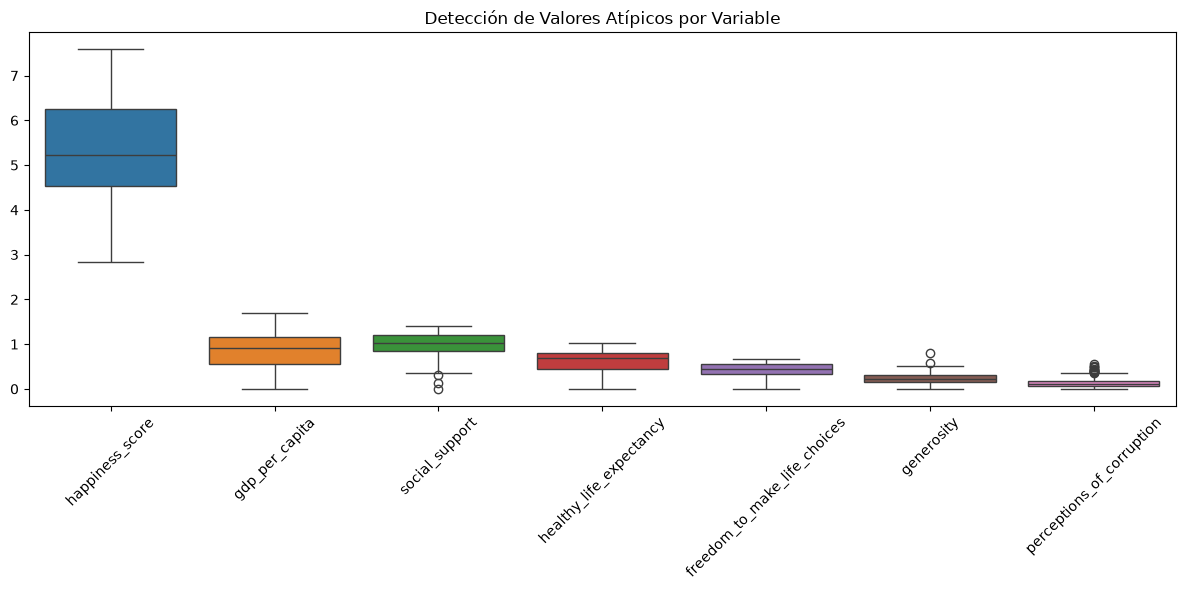

In [12]:
# Usamos IQR para identificar valores atípicos (Outliers) en las columnas numéricas
Q1 = df.select_dtypes(include=np.number).quantile(0.25)
Q3 = df.select_dtypes(include=np.number).quantile(0.75)
IQR = Q3 - Q1

# Mostramos los valores atípicos por columna
outliers = {}
for col in df.select_dtypes(include=np.number).columns:
    outliers[col] = df[(df[col] < (Q1[col] - 1.5 * IQR[col])) | (df[col] > (Q3[col] + 1.5 * IQR[col]))][col]
    print(f"Valores atípicos en '{col}': {outliers[col].tolist()}")

#Identificar valores atípicos (Outliers) mediante Boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=45)
plt.title('Detección de Valores Atípicos por Variable')
plt.tight_layout()
plt.show()

# 3. Analizar las variables categóricas

Existen 2 variables categoricas país y región.

Tablas de Frecuencia Absoluta, relativa y porcentajes.

En este caso se esperaria que "country" tuviera las mismas frecuencias para todos los países.

In [13]:
# Tabla de Frecuencias Absolutas, Relativa y Porcentual de la variable 'country'
freq_abs_country = df["country"].value_counts()
freq_rel_country = df["country"].value_counts(normalize=True)
freq_rel_porcentual_country = freq_rel_country * 100

tabla_country = pd.DataFrame(
    {"Frecuencia Absoluta": freq_abs_country, "Frecuencia Relativa": freq_rel_country.round(5), "Porcentaje (%)": freq_rel_porcentual_country.round(2)}
)

print("=== TABLA DE FRECUENCIAS: COUNTRY ===")
print(tabla_country)
print("\nVerificación del Total de Porcentajes:", freq_rel_porcentual_country.sum().round(2), "%")

=== TABLA DE FRECUENCIAS: COUNTRY ===
             Frecuencia Absoluta  Frecuencia Relativa  Porcentaje (%)
country                                                              
Switzerland                    1              0.00633            0.63
Iceland                        1              0.00633            0.63
Denmark                        1              0.00633            0.63
Norway                         1              0.00633            0.63
Canada                         1              0.00633            0.63
...                          ...                  ...             ...
Rwanda                         1              0.00633            0.63
Benin                          1              0.00633            0.63
Syria                          1              0.00633            0.63
Burundi                        1              0.00633            0.63
Togo                           1              0.00633            0.63

[158 rows x 3 columns]

Verificación del Total de P

In [14]:
# Tabla de Frecuencias Absolutas, Relativa y Porcentual de la variable 'region'
freq_abs = df["region"].value_counts()
freq_rel = df["region"].value_counts(normalize=True)
freq_rel_porcentual = freq_rel * 100

tabla_region = pd.DataFrame(
    {"Frecuencia Absoluta": freq_abs, "Frecuencia Relativa": freq_rel.round(5), "Porcentaje (%)": freq_rel_porcentual.round(2)}
)

print("=== TABLA DE FRECUENCIAS: REGIÓN ===")
print(tabla_region)
print("\nVerificación del Total de Porcentajes:", freq_rel_porcentual.sum().round(2), "%")

=== TABLA DE FRECUENCIAS: REGIÓN ===
                                    Frecuencia Absoluta  Frecuencia Relativa  \
region                                                                         
Sub-Saharan Africa                                   39              0.24684   
Central and Eastern Europe                           24              0.15190   
Latin America and Caribbean                          22              0.13924   
Western Europe                                       21              0.13291   
Middle East and North Africa                         20              0.12658   
Southeast Asia                                        9              0.05696   
South Asia                                            7              0.04430   
East Asia                                             6              0.03797   
Commonwealth of Independent States                    5              0.03165   
North America and ANZ                                 4              0.02532   
Afr

### Identificar Categoria Modal

En este caso "country" no tiene una categoría modal al no tener mas de una repetición de cada elemento

In [15]:
# Identificación de la Categoría Modal de la variable 'country'
categoria_modal_country = freq_abs_country.idxmax()
frecuencia_modal_country = freq_abs_country.max()
print(f"\nCategoría Modal de 'country': '{categoria_modal_country}' con {frecuencia_modal_country} países.")


Categoría Modal de 'country': 'Switzerland' con 1 países.


In [16]:

# Identificación de la Categoría Modal de la variable 'region'
categoria_modal = freq_abs.idxmax()
frecuencia_modal = freq_abs.max()
print(f"\nCategoría Modal: '{categoria_modal}' con {frecuencia_modal} países.")


Categoría Modal: 'Sub-Saharan Africa' con 39 países.


### Identificar categorías poco frecuentes

En este caso "country" no tiene varianza en las frecuencias al no tener mas de una repetición de cada elemento

In [17]:
# Identificación de Categorías Poco Frecuentes para la variable 'country'
umbral_bajo = 5  # Porcentaje arbitrario bajo (ej. menos del 5% de los países)
poco_frecuentes = tabla_country[tabla_country["Porcentaje (%)"] < umbral_bajo]
print("\nCategorías Poco Frecuentes (< 5% del total):")
print(poco_frecuentes)



Categorías Poco Frecuentes (< 5% del total):
             Frecuencia Absoluta  Frecuencia Relativa  Porcentaje (%)
country                                                              
Switzerland                    1              0.00633            0.63
Iceland                        1              0.00633            0.63
Denmark                        1              0.00633            0.63
Norway                         1              0.00633            0.63
Canada                         1              0.00633            0.63
...                          ...                  ...             ...
Rwanda                         1              0.00633            0.63
Benin                          1              0.00633            0.63
Syria                          1              0.00633            0.63
Burundi                        1              0.00633            0.63
Togo                           1              0.00633            0.63

[158 rows x 3 columns]


In [18]:
# Identificación de Categorías Poco Frecuentes para la variable 'region'
umbral_bajo = 5  # Porcentaje arbitrario bajo (ej. menos del 5% de los países)
poco_frecuentes = tabla_region[tabla_region["Porcentaje (%)"] < umbral_bajo]
print("\nCategorías Poco Frecuentes (< 5% del total):")
print(poco_frecuentes)



Categorías Poco Frecuentes (< 5% del total):
                                    Frecuencia Absoluta  Frecuencia Relativa  \
region                                                                         
South Asia                                            7              0.04430   
East Asia                                             6              0.03797   
Commonwealth of Independent States                    5              0.03165   
North America and ANZ                                 4              0.02532   
Africa                                                1              0.00633   

                                    Porcentaje (%)  
region                                              
South Asia                                    4.43  
East Asia                                     3.80  
Commonwealth of Independent States            3.16  
North America and ANZ                         2.53  
Africa                                        0.63  


### Grafica de barras ordenada

En este caso para países se puede esperar que todas las barras esten a la misma altura al tener la misma frecuencia cada pais

/tmp/ipykernel_43759/2107664352.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


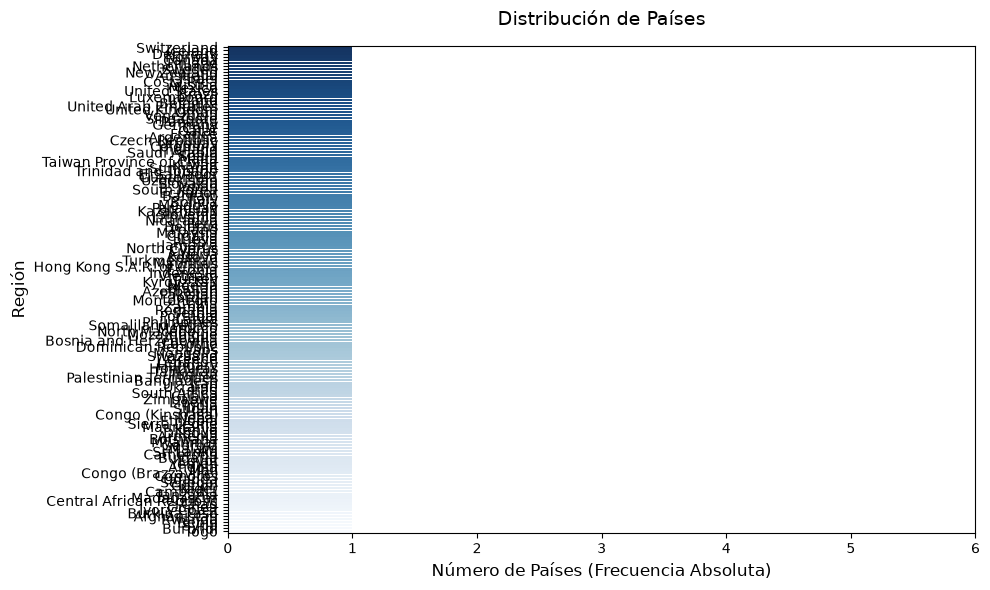

In [19]:
# Visualización de la Distribución de Países

plt.figure(figsize=(10, 6))

# Orden de barras por frecuencia descendente
order = freq_abs_country.index

ax = sns.barplot(
    y=freq_abs_country.index, x=freq_abs_country.values, palette="Blues_r", order=order
)

plt.title(
    "Distribución de Países",
    fontsize=14,
    pad=15,
)
plt.xlabel("Número de Países (Frecuencia Absoluta)", fontsize=12)
plt.ylabel("Región", fontsize=12)

# Añadir etiquetas de frecuencia y porcentaje en cada barra

plt.xlim(0, max(freq_abs_country.values) + 5)  # Espacio para las etiquetas
plt.tight_layout()
plt.show()

/tmp/ipykernel_43759/2056605710.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


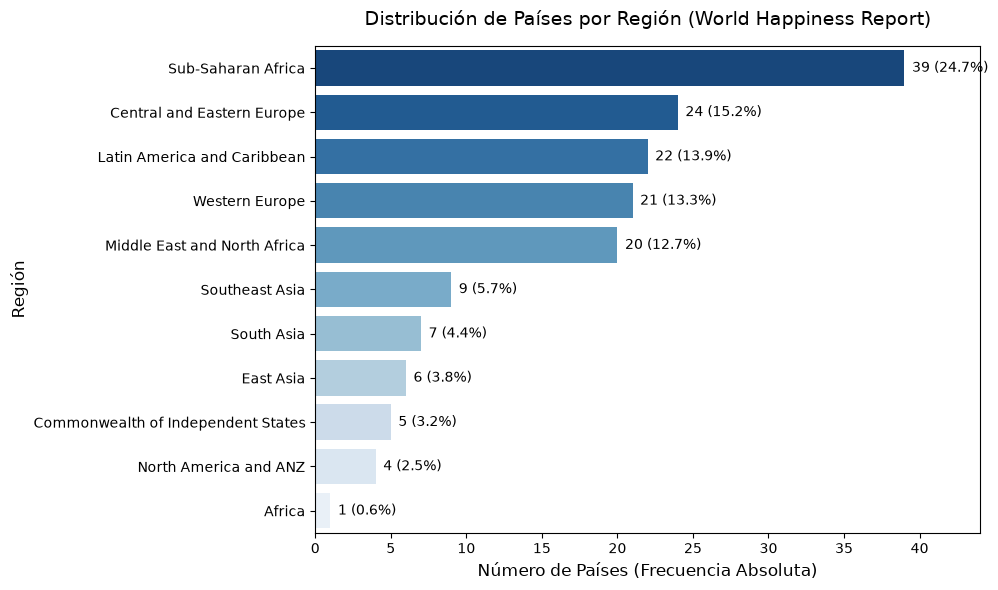

In [20]:


plt.figure(figsize=(10, 6))

# Orden de barras por frecuencia descendente
order = freq_abs.index

ax = sns.barplot(
    y=freq_abs.index, x=freq_abs.values, palette="Blues_r", order=order
)

plt.title(
    "Distribución de Países por Región (World Happiness Report)",
    fontsize=14,
    pad=15,
)
plt.xlabel("Número de Países (Frecuencia Absoluta)", fontsize=12)
plt.ylabel("Región", fontsize=12)

# Añadir etiquetas de frecuencia y porcentaje en cada barra
total_paises = len(df)
for p in ax.patches:
    width = p.get_width()
    percentage = (width / total_paises) * 100
    ax.annotate(
        f"{int(width)} ({percentage:.1f}%)",
        (width + 0.5, p.get_y() + p.get_height() / 2.0),
        ha="left",
        va="center",
        fontsize=10,
    )

plt.xlim(0, max(freq_abs.values) + 5)  # Espacio para las etiquetas
plt.tight_layout()
plt.show()

## Analisís de las variables numéricas 

Como sabemos las variables numéricas existentes son 7: 

- happiness_score
- gdp_per_capita
- social_support
- healthy_life_expectancy
- freedom_to_make_life_choices
- generosity
- perceptions_of_corruption


In [24]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

### Tabla de estadisticos descriptivos

Procederemos a calcular media, mediana, mínimo, máximo, varianza, IQR, asimetría y kurtosis, para todas las variables numéricas.

In [22]:

resumen_numerico = pd.DataFrame(index=numeric_cols)

# Número de observaciones válidas
resumen_numerico["N"] = df[numeric_cols].count()

# Medidas de tendencia central
resumen_numerico["Media"] = df[numeric_cols].mean()
resumen_numerico["Mediana"] = df[numeric_cols].median()

# Medidas de posición
resumen_numerico["Mínimo"] = df[numeric_cols].min()
resumen_numerico["Q1"] = df[numeric_cols].quantile(0.25)
resumen_numerico["Q3"] = df[numeric_cols].quantile(0.75)
resumen_numerico["Máximo"] = df[numeric_cols].max()

# Medidas de dispersión
resumen_numerico["Varianza"] = df[numeric_cols].var()
resumen_numerico["Desviación estándar"] = df[numeric_cols].std()

# Rango intercuartil
resumen_numerico["IQR"] = (
    resumen_numerico["Q3"] - resumen_numerico["Q1"]
)

# Forma de la distribución
resumen_numerico["Asimetría"] = df[numeric_cols].skew()
resumen_numerico["Curtosis (exceso)"] = df[numeric_cols].kurt()

# Mostrar resultados
display(resumen_numerico.round(4))

,N,Media,Mediana,Mínimo,Q1,Q3,Máximo,Varianza,Desviación estándar,IQR,Asimetría,Curtosis (exceso)
happiness_score,158,5.3757,5.2325,2.839,4.5260,6.2438,7.5870,1.3110,1.1450,1.7178,0.0978,-0.7761
gdp_per_capita,158,0.8461,0.9102,0.000,0.5458,1.1584,1.6904,0.1625,0.4031,0.6126,-0.3176,-0.8670
social_support,158,0.9910,1.0295,0.000,0.8568,1.2144,1.4022,0.0742,0.2724,0.3576,-1.0069,0.9188
healthy_life_expectancy,158,0.6303,0.6967,0.000,0.4392,0.8110,1.0252,0.0610,0.2471,0.3718,-0.7053,-0.3939
freedom_to_make_life_choices,158,0.4286,0.4355,0.000,0.3283,0.5491,0.6697,0.0227,0.1507,0.2208,-0.4135,-0.4608
generosity,158,0.2373,0.2161,0.000,0.1506,0.3099,0.7959,0.0160,0.1267,0.1593,1.0020,1.7465
perceptions_of_corruption,158,0.1434,0.1072,0.000,0.0617,0.1803,0.5519,0.0144,0.1200,0.1186,1.3855,1.3848


## Comparación entre media y mediana

In [23]:

comparacion_media_mediana = pd.DataFrame({
    "Media": df[numeric_cols].mean(),
    "Mediana": df[numeric_cols].median()
})

comparacion_media_mediana["Diferencia (Media - Mediana)"] = (
    comparacion_media_mediana["Media"]
    - comparacion_media_mediana["Mediana"]
)

display(comparacion_media_mediana.round(4))

,Media,Mediana,Diferencia (Media - Mediana)
happiness_score,5.3757,5.2325,0.1432
gdp_per_capita,0.8461,0.9102,-0.0641
social_support,0.9910,1.0295,-0.0385
healthy_life_expectancy,0.6303,0.6967,-0.0664
freedom_to_make_life_choices,0.4286,0.4355,-0.0069
generosity,0.2373,0.2161,0.0212
perceptions_of_corruption,0.1434,0.1072,0.0362


Las siete variables numéricas cuentan con 158 observaciones válidas. La
comparación entre media, mediana y coeficiente de asimetría muestra
diferencias importantes en la forma de sus distribuciones.

Se observa que la mediana en la mayoría de las variables tienen una mediana superior a la media, sugiriendo colas hacia la izquierda. Con mayor simetria cercana a 0 (0.0978) en "happiness_score" y simetria positiva en "perceptions_of_corruption"  (1.3855) y "generosity" (1.0020) y.

Por otra parte, "social_support" (-1.0069) y
"healthy_life_expectancy" (-0.7053) presentan asimetría negativa,
mientras que "gdp_per_capita" (-0.3176) y
"freedom_to_make_life_choices" (-0.4135) muestran una asimetría negativa
menos pronunciada.



## Histogramas & Kernel Density Estimation

Se hará una gráfica por variable para observar mjor la dirección y longitud de las colas.

In [ ]:

for col in numeric_cols:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        bins="auto"
        color="orange"
    )

    # Media y mediana como referencia
    plt.axvline(
        df[col].mean(),
        linestyle="--",
        label=f"Media = {df[col].mean():.3f}"
    )

    plt.axvline(
        df[col].median(),
        linestyle=":",
        label=f"Mediana = {df[col].median():.3f}"
    )

    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.legend()

    plt.tight_layout()
    plt.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (4241298742.py, line 8)

## Boxplots de cada variables

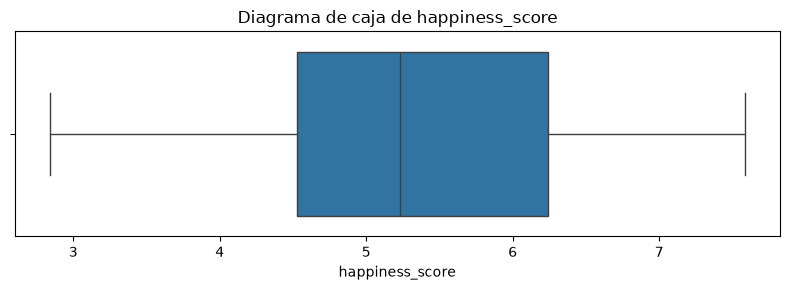

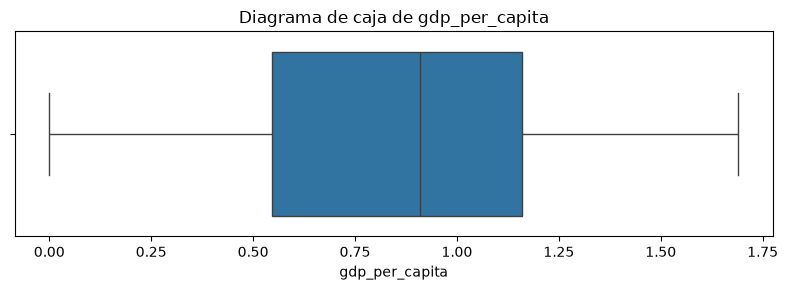

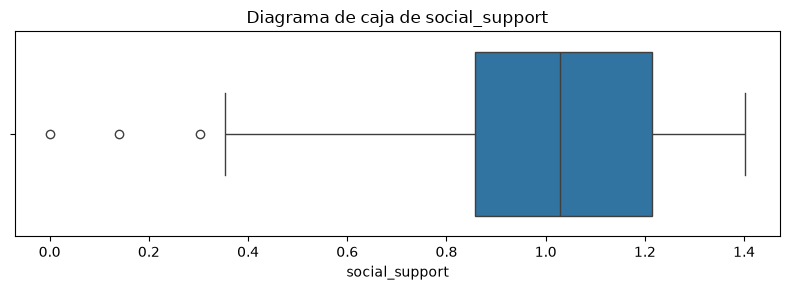

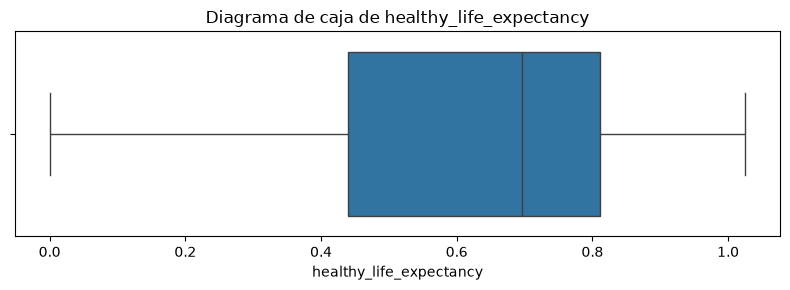

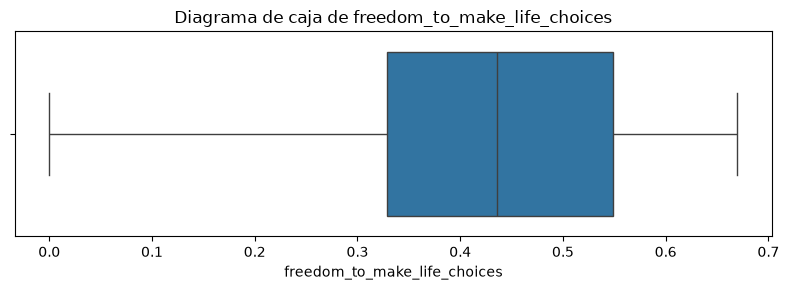

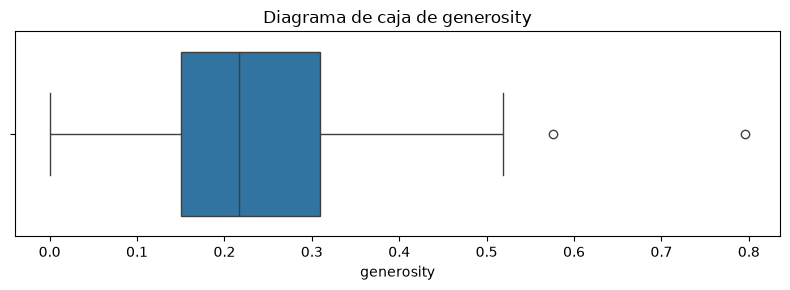

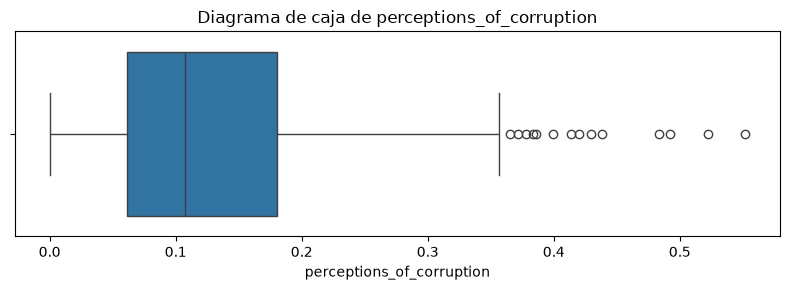

In [26]:

for col in numeric_cols:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Diagrama de caja de {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

## Detección de outliers con IQR

In [27]:

resultados_iqr = []

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mask_iqr = (
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    )

    resultados_iqr.append({
        "Variable": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Número de outliers IQR": mask_iqr.sum()
    })

tabla_iqr = pd.DataFrame(resultados_iqr)

display(tabla_iqr.round(4))

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Número de outliers IQR
0,happiness_score,4.5260,6.2438,1.7178,1.9494,8.8204,0
1,gdp_per_capita,0.5458,1.1584,0.6126,-0.3732,2.0774,0
2,social_support,0.8568,1.2144,0.3576,0.3204,1.7508,3
3,healthy_life_expectancy,0.4392,0.8110,0.3718,-0.1186,1.3688,0
4,freedom_to_make_life_choices,0.3283,0.5491,0.2208,-0.0028,0.8802,0
5,generosity,0.1506,0.3099,0.1593,-0.0884,0.5489,2
6,perceptions_of_corruption,0.0617,0.1803,0.1186,-0.1162,0.3581,14


## Detectando outliers con Z-score 

In [28]:

z_scores = (
    df[numeric_cols] - df[numeric_cols].mean()
) / df[numeric_cols].std()

# Identificar posibles outliers usando |z| > 3

resultados_zscore = []

for col in numeric_cols:

    mask_z = z_scores[col].abs() > 3

    resultados_zscore.append({
        "Variable": col,
        "Número de outliers Z-score": mask_z.sum()
    })

tabla_zscore = pd.DataFrame(resultados_zscore)

display(tabla_zscore)

,Variable,Número de outliers Z-score
0,happiness_score,0
1,gdp_per_capita,0
2,social_support,2
3,healthy_life_expectancy,0
4,freedom_to_make_life_choices,0
5,generosity,1
6,perceptions_of_corruption,2


## Comparación de IQR contra z-score

In [30]:
comparacion_outliers = []

for col in numeric_cols:

    # IQR 
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mask_iqr = (
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    )

    # Z-score
    media = df[col].mean()
    std = df[col].std()

    z = (df[col] - media) / std
    mask_z = z.abs() > 3

    # Comparacion
    comparacion_outliers.append({
        "Variable": col,
        "Outliers IQR": mask_iqr.sum(),
        "Outliers Z-score": mask_z.sum(),
        "Detectados por ambos": (mask_iqr & mask_z).sum(),
        "Solo IQR": (mask_iqr & ~mask_z).sum(),
        "Solo Z-score": (~mask_iqr & mask_z).sum()
    })

tabla_comparacion_outliers = pd.DataFrame(comparacion_outliers)

display(tabla_comparacion_outliers)

,Variable,Outliers IQR,Outliers Z-score,Detectados por ambos,Solo IQR,Solo Z-score
0,happiness_score,0,0,0,0,0
1,gdp_per_capita,0,0,0,0,0
2,social_support,3,2,2,1,0
3,healthy_life_expectancy,0,0,0,0,0
4,freedom_to_make_life_choices,0,0,0,0,0
5,generosity,2,1,1,1,0
6,perceptions_of_corruption,14,2,2,12,0


### Detección de posibles valores atípico 

In [31]:

detalle_outliers = []

for col in numeric_cols:

    # IQR 
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    mask_iqr = (
        (df[col] < limite_inferior) |
        (df[col] > limite_superior)
    )

    # Z-score 
    z = (df[col] - df[col].mean()) / df[col].std()
    mask_z = z.abs() > 3

    # Registros detectados por cualquiera de los dos metodos
    mask_total = mask_iqr | mask_z

    temp = df.loc[
        mask_total,
        ["country", "region", col]
    ].copy()

    temp = temp.rename(columns={col: "Valor"})

    temp["Variable"] = col
    temp["Outlier IQR"] = mask_iqr.loc[temp.index]
    temp["Outlier Z-score"] = mask_z.loc[temp.index]
    temp["Z-score"] = z.loc[temp.index]

    detalle_outliers.append(temp)

if detalle_outliers:
    detalle_outliers = pd.concat(
        detalle_outliers,
        ignore_index=True
    )

    detalle_outliers = detalle_outliers[
        [
            "Variable",
            "country",
            "region",
            "Valor",
            "Outlier IQR",
            "Outlier Z-score",
            "Z-score"
        ]
    ]

    display(detalle_outliers.round(4))
else:
    print("No se detectaron posibles valores atípicos.")

,Variable,country,region,Valor,Outlier IQR,Outlier Z-score,Z-score
0,social_support,Central African Republic,Sub-Saharan Africa,0.0000,True,True,-3.6386
1,social_support,Afghanistan,South Asia,0.3028,True,False,-2.5267
2,social_support,Togo,Sub-Saharan Africa,0.1400,True,True,-3.1248
3,generosity,Thailand,Southeast Asia,0.5763,True,False,2.6760
4,generosity,Myanmar,Southeast Asia,0.7959,True,True,4.4092
5,perceptions_of_corruption,Switzerland,Western Europe,0.4198,True,False,2.3023
6,perceptions_of_corruption,Denmark,Western Europe,0.4836,True,False,2.8338
7,perceptions_of_corruption,Norway,Western Europe,0.3650,True,False,1.8462
8,perceptions_of_corruption,Finland,Western Europe,0.4137,True,False,2.2518
9,perceptions_of_corruption,Sweden,Western Europe,0.4384,True,False,2.4578
